# 3.1 The dot product

## Length of vectors

Now we turn to the more geometric concepts relating to vectors. We start by defining the length of the vector and generalize this to the concept of the _dot product_, which measures the similarity between two vectors. The dot product is very important in many applications, including machine learning and physics.

Given a vector $\vec v = \begin{bmatrix} x_1 \\ \vdots \\ x_n \end{bmatrix}$, the **length** (or the **norm**) of the $\vec v$ is defined by
$$ \| \vec v\| = \sqrt{x_1^2 + \ldots + x_n^2}.$$

This is the generalization of the Pythagorean theorem to $n$-dimensions. Indeed, let us check that this definition of length matches the usual notion of lengths for dimension 2. If we have a vector $\vec v = \begin{bmatrix} 3 \\ 4 \end{bmatrix}$, then the length of $\vec v$ is $\| \vec v\| = \sqrt{3^2 + 4^2} = 5$. This is precisely the length of the hypotenuse of a right triangle with legs of length 3 and 4, which we obtain by applying the Pythagorean theorem to the decomposition we saw last class:

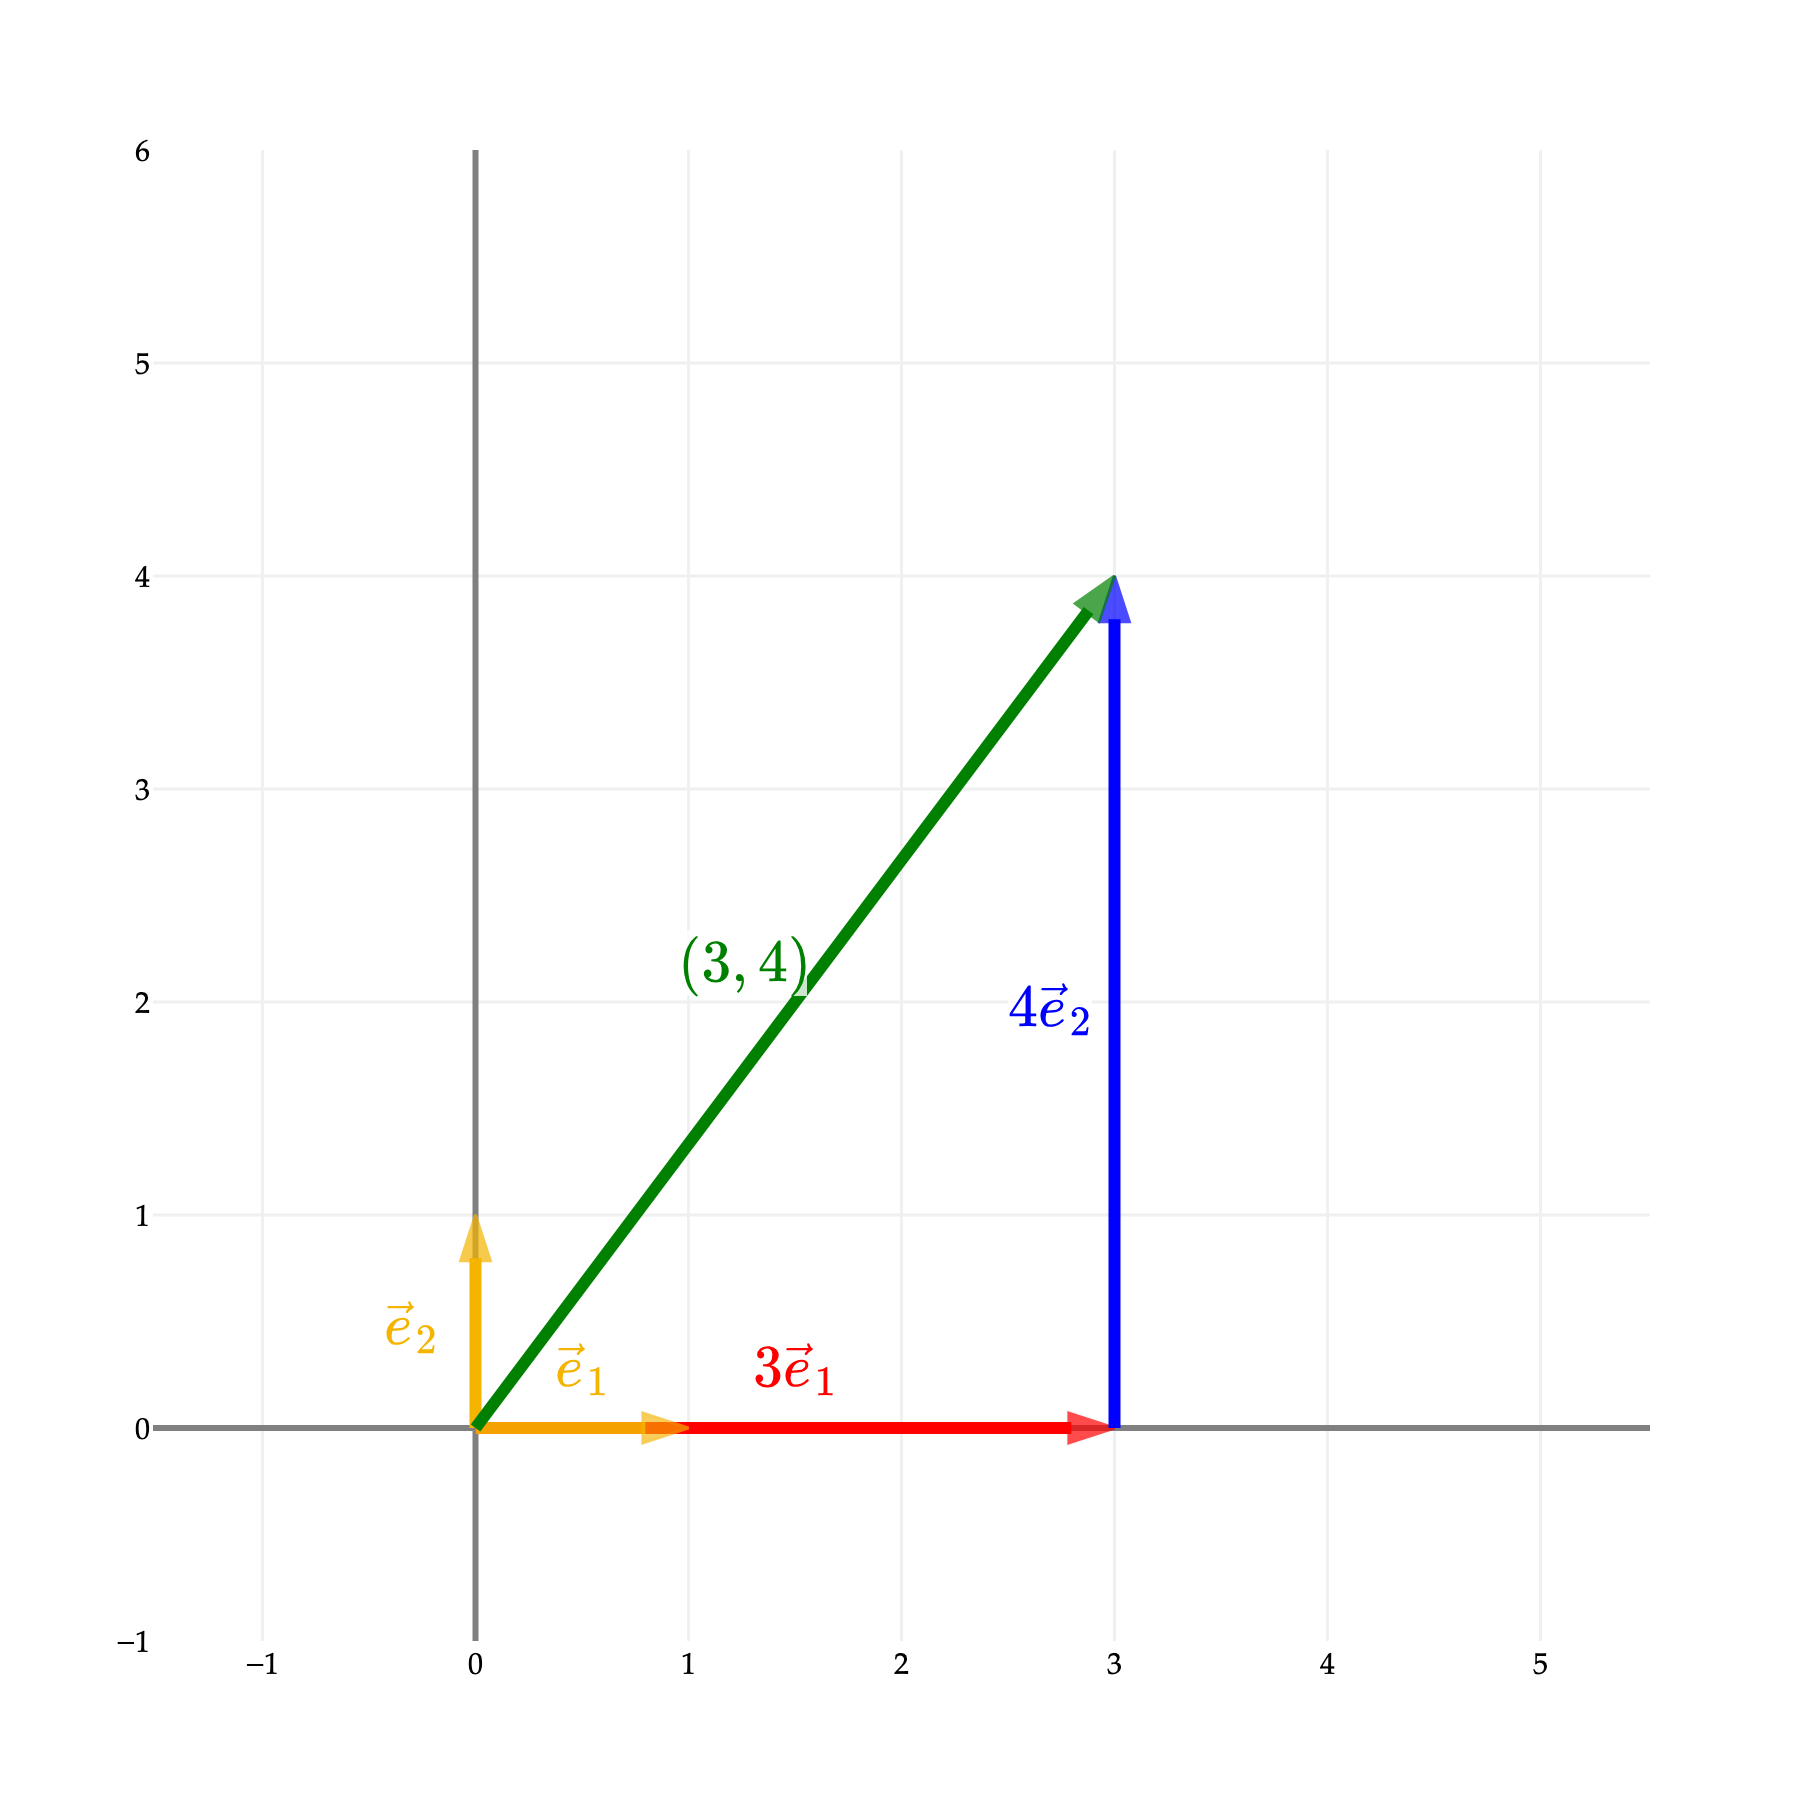

In [22]:
from IPython.display import display, HTML
import plotly.io as pio
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))

# ---
from utils import plot_vectors_non_origin

# Define vectors: (((start_x, start_y), (end_x, end_y)), color, label)
vectors = [
    # 1. The horizontal scaled basis vector (drawn first so it sits at the bottom)
    (((0, 0), (3, 0)), 'red', r'$3\vec{e}_1$'),
    
    # 2. The standard unit vectors (gold)
    # Using slight transparency on e_1 so the red line beneath it remains visible
    (((0, 0), (1, 0)), 'rgba(244, 180, 0, 0.9)', r'$\vec{e}_1$'),
    (((0, 0), (0, 1)), '#f4b400', r'$\vec{e}_2$'),
    
    # 3. The vertical scaled vector, starting from the tip of 3e_1
    (((3, 0), (3, 4)), 'blue', r'$4\vec{e}_2$'),
    
    # 4. The resultant vector
    (((0, 0), (3, 4)), 'green', r'$(3,4)$')
]

# Adjust label offsets to clear the lines
fig = plot_vectors_non_origin(vectors, vdeltax=0.3, vdeltay=0.3)

# Lock the aspect ratio so the spatial proportions are mathematically accurate
fig.update_layout(width=600, height=600, yaxis_scaleanchor="x")

# Set the grid range to comfortably frame the entire geometric decomposition
fig.update_xaxes(range=[-1, 5], tickvals=np.arange(-1, 6))
fig.update_yaxes(range=[-1, 6], tickvals=np.arange(-1, 7))

fig.show(scale=3)

A similar argument shows that this definition of length matches the usual notion of lengths for dimension 3 as well. We demonstrate this with the example of the vector $\vec v = \begin{bmatrix} 3 \\ 4 \\ 5 \end{bmatrix}$. The length of $\vec v$ is $\| \vec v\| = \sqrt{3^2 + 4^2 + 5^2} = \sqrt{50}$. We can also compute the length of $\vec v$ by applying the Pythagorean theorem twice after decomposing $\vec v$  as follows:

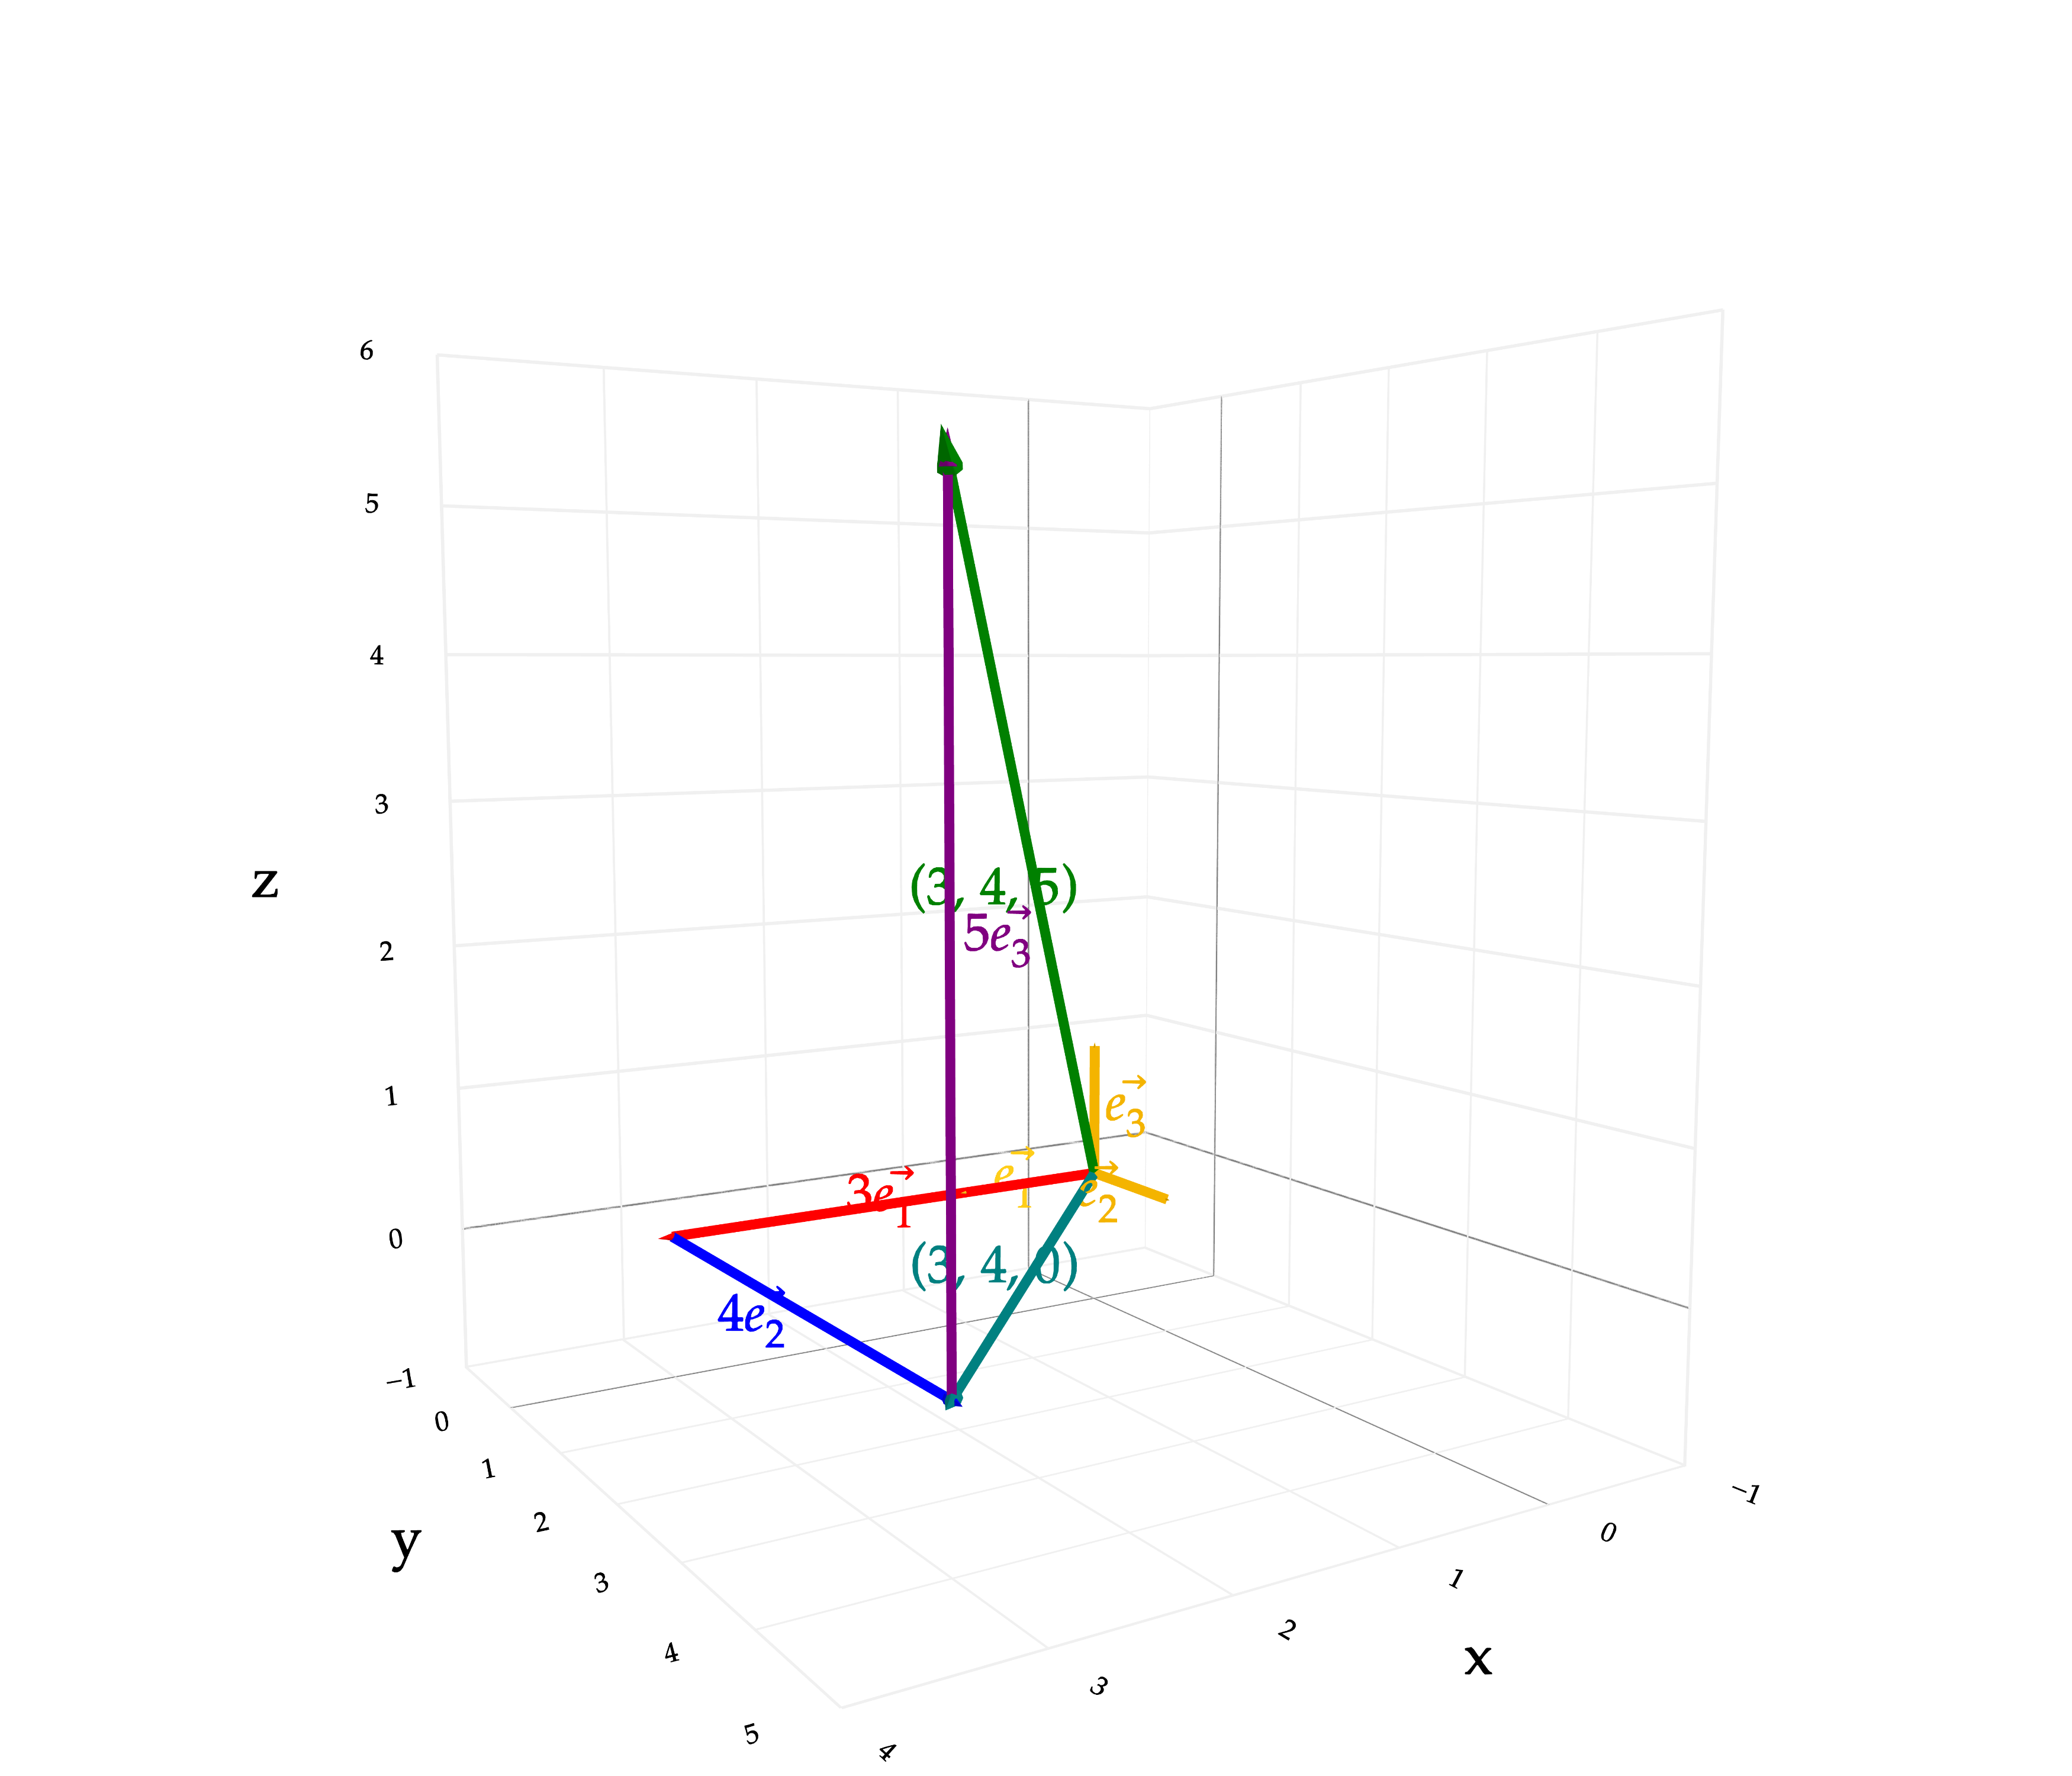

In [23]:
from IPython.display import display, HTML
import plotly.io as pio
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))

# ---
from utils import plot_vectors_non_origin

# Define 3D vectors: (((start_x, start_y, start_z), (end_x, end_y, end_z)), color, label)
vectors = [
    # 1. The standard unit basis vectors (gold, drawn at the origin)
    (((0, 0, 0), (1, 0, 0)), 'rgba(244, 180, 0, 0.9)', '<i>e</i><sub>1</sub>\u20D7'),
    (((0, 0, 0), (0, 1, 0)), '#f4b400', '<i>e</i><sub>2</sub>\u20D7'),
    (((0, 0, 0), (0, 0, 1)), '#f4b400', '<i>e</i><sub>3</sub>\u20D7'),
    
    # 2. The scaled components forming the decomposition path
    (((0, 0, 0), (3, 0, 0)), 'red', '3<i>e</i><sub>1</sub>\u20D7'),     # Along x-axis
    (((3, 0, 0), (3, 4, 0)), 'blue', '4<i>e</i><sub>2</sub>\u20D7'),     # Parallel to y-axis
    
    # 3. NEW: The intermediate resultant in the xy-plane (Hypotenuse 1)
    (((0, 0, 0), (3, 4, 0)), 'teal', '(3, 4, 0)'),
    
    # 4. The vertical z-component
    (((3, 4, 0), (3, 4, 5)), 'purple', '5<i>e</i><sub>3</sub>\u20D7'),   # Parallel to z-axis
    
    # 5. The final resultant vector from the origin (Hypotenuse 2)
    (((0, 0, 0), (3, 4, 5)), 'green', '(3, 4, 5)')
]

# Slightly increased offsets for the 3D labels as the space is getting crowded
fig = plot_vectors_non_origin(vectors, vdeltax=0.5, vdeltay=0.5, vdeltaz=0.5)

# Frame the grid and force integer ticks (dtick=1) on all axes
fig.update_layout(
    width=700, 
    height=600,
    scene=dict(
        xaxis=dict(range=[-1, 4], dtick=1),
        yaxis=dict(range=[-1, 5], dtick=1),
        zaxis=dict(range=[-1, 6], dtick=1),
        aspectratio=dict(x=1, y=1, z=1.2) # Keeps the spatial proportions cubic/natural
    )
)

fig.show(scale=5)

More specifically, we apply the Pythagorean theorem
* first to the triangle formed by the red, blue and teal vectors to obtain that the teal vectors has length
$$ \sqrt{3^2 + 4^2} = \sqrt 25 = 5;$$
* and then to the triangle formed by the teal, purple and yellow vectors to obtain that the green vector has length
$$ \sqrt{5^2 + 5^2 } = \sqrt 50 = 5\sqrt{2}.$$

### The triangle inequality

A fundamental principle of geometry is that the shortest path between two points is a straight line. If you want to go from point $A$ to point $C$, taking a detour through a third point $B$ will always mean you travel a greater (or equal) distance. Simply put, the length of any one side of a triangle is always less than or equal to the sum of the lengths of the other two sides.

We can reframe this intuitive geometric fact using vectors. Suppose $\vec{u}$ represents the journey from $A$ to $B$, and $\vec{v}$ represents the journey from $B$ to $C$. Recall from the last section's geometric interpretation of vector addition that he direct path from $A$ to $C$ is exactly their vector addition: $\vec{u} + \vec{v}$. 


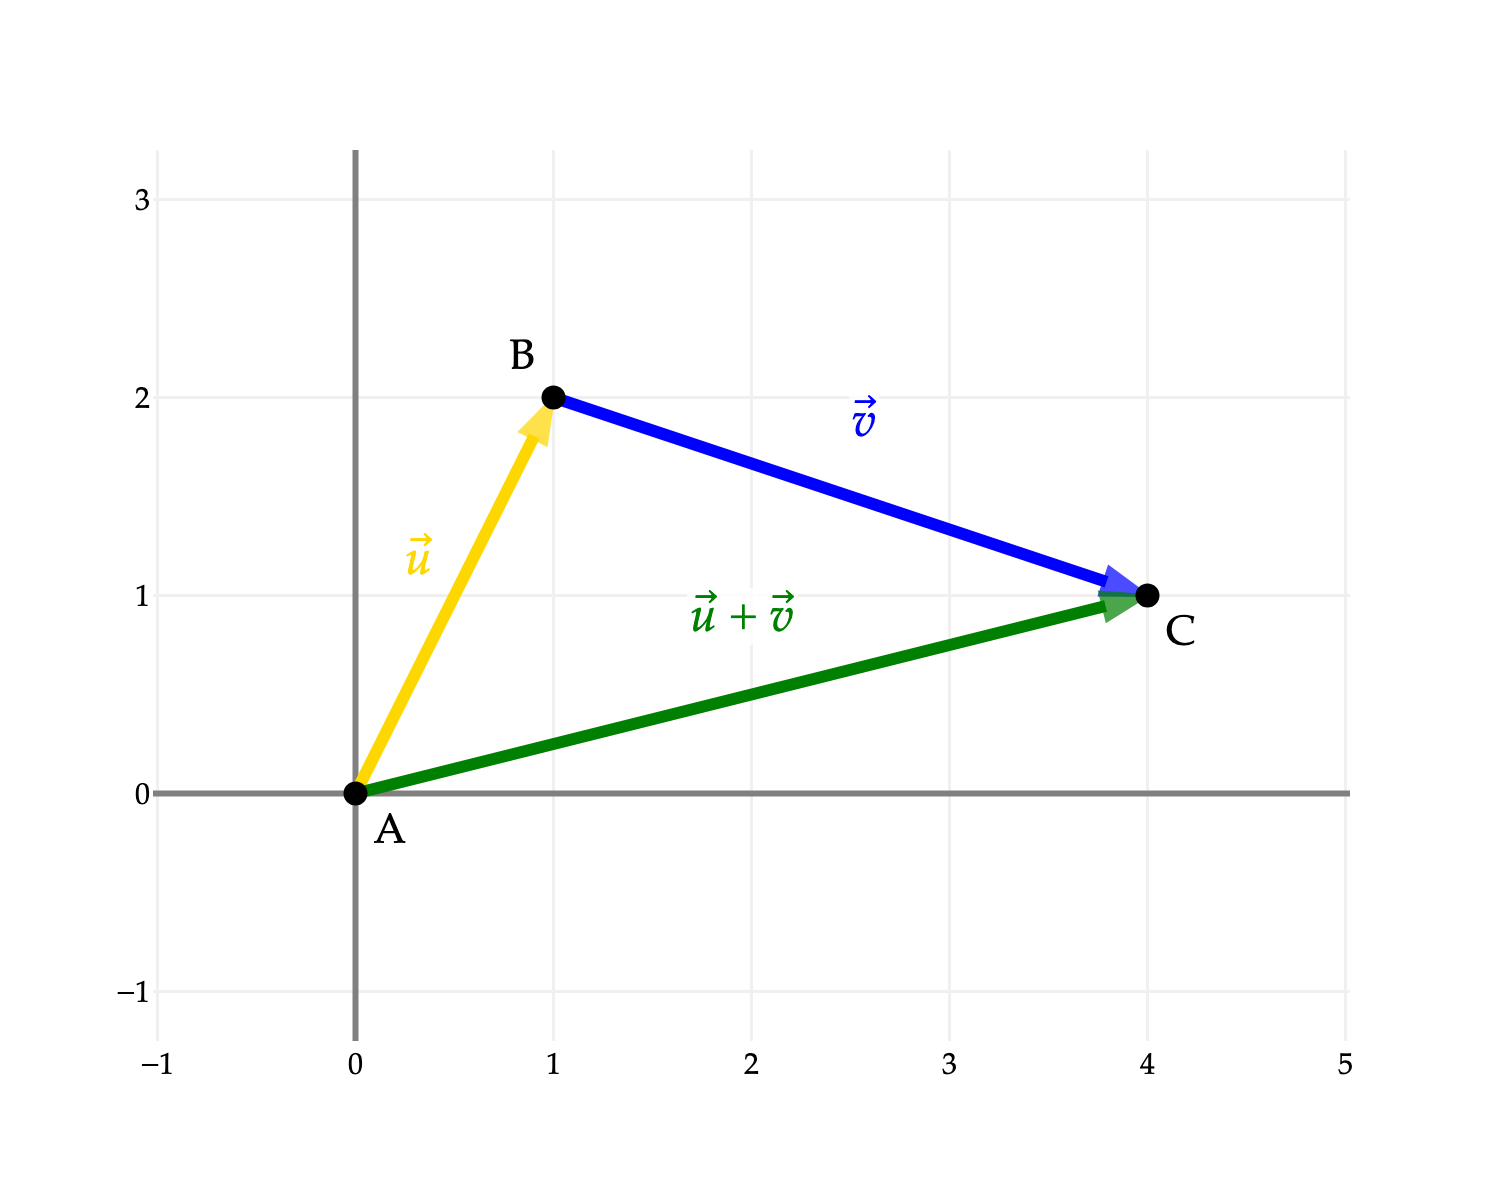

In [ ]:
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"

# ---
from utils import plot_vectors_non_origin

# Define vectors using standard strings and Unicode arrows (\u20D7) to prevent Error 525
vectors = [
    (((0, 0), (1, 2)), 'gold', '<i>u</i>\u20D7'),                # u starts at origin
    (((1, 2), (4, 1)), 'blue', '<i>v</i>\u20D7'),                # v starts at tip of u
    (((0, 0), (4, 1)), 'green', '<i>u</i>\u20D7 + <i>v</i>\u20D7') # u+v starts at origin, ends at tip of v
]

fig = plot_vectors_non_origin(vectors, vdeltax=0.2, vdeltay=0.4)

# Explicitly mark and label points A, B, and C

fig.update_layout(width=500, height=400, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-1, 5], tickvals=np.arange(-2, 7))
fig.update_yaxes(range=[-1, 3], tickvals=np.arange(-2, 5))

fig.show(scale=3)

Because the direct path is always the shortest, the magnitude (or length) of the total journey cannot exceed the lengths of the individual segments. This gives us the **triangle inequality** for vectors:

$$\|\vec{u} + \vec{v}\| \leq \|\vec{u}\| + \|\vec{v}\|.$$

## Distance Between Points

Now that we have established the notion of the length of a vector, we can use it to calculate the distance between two points in Euclidean space. 

Given two points $A = (x_1, \ldots, x_n)$ and $B = (y_1, \ldots, y_n)$ in $n$-dimensional space, the distance between them is defined explicitly in coordinates as:
$$ d(A, B) = \sqrt{(x_1 - y_1)^2 + \ldots + (x_n - y_n)^2}$$

We can justify this intuitively using the geometry of vector subtraction that we have seen in the last chapter. Let the points $A$ and $B$ be represented by their position vectors
$$ \vec u = \begin{bmatrix} x_1 \\ \vdots \\ x_n \end{bmatrix} \text { and } \vec v = \begin{bmatrix} y_1 \\ \vdots \\ y_n \end{bmatrix},$$ which extend from the origin to the each respective points. The straight line segment connecting $B$ to $A$ is represented by the vector $$\vec{u} - \vec{v} = \begin{bmatrix} x_1 - y_1 \\ \vdots \\ x_n - y_n \end{bmatrix}.$$
Hence the distance between the original points $A$ and $B$ is simply the length of this connecting vector: $\|\vec{u} - \vec{v}\| = \sqrt{(x_1 - y_1)^2 + \ldots + (x_n - y_n)^2}$.

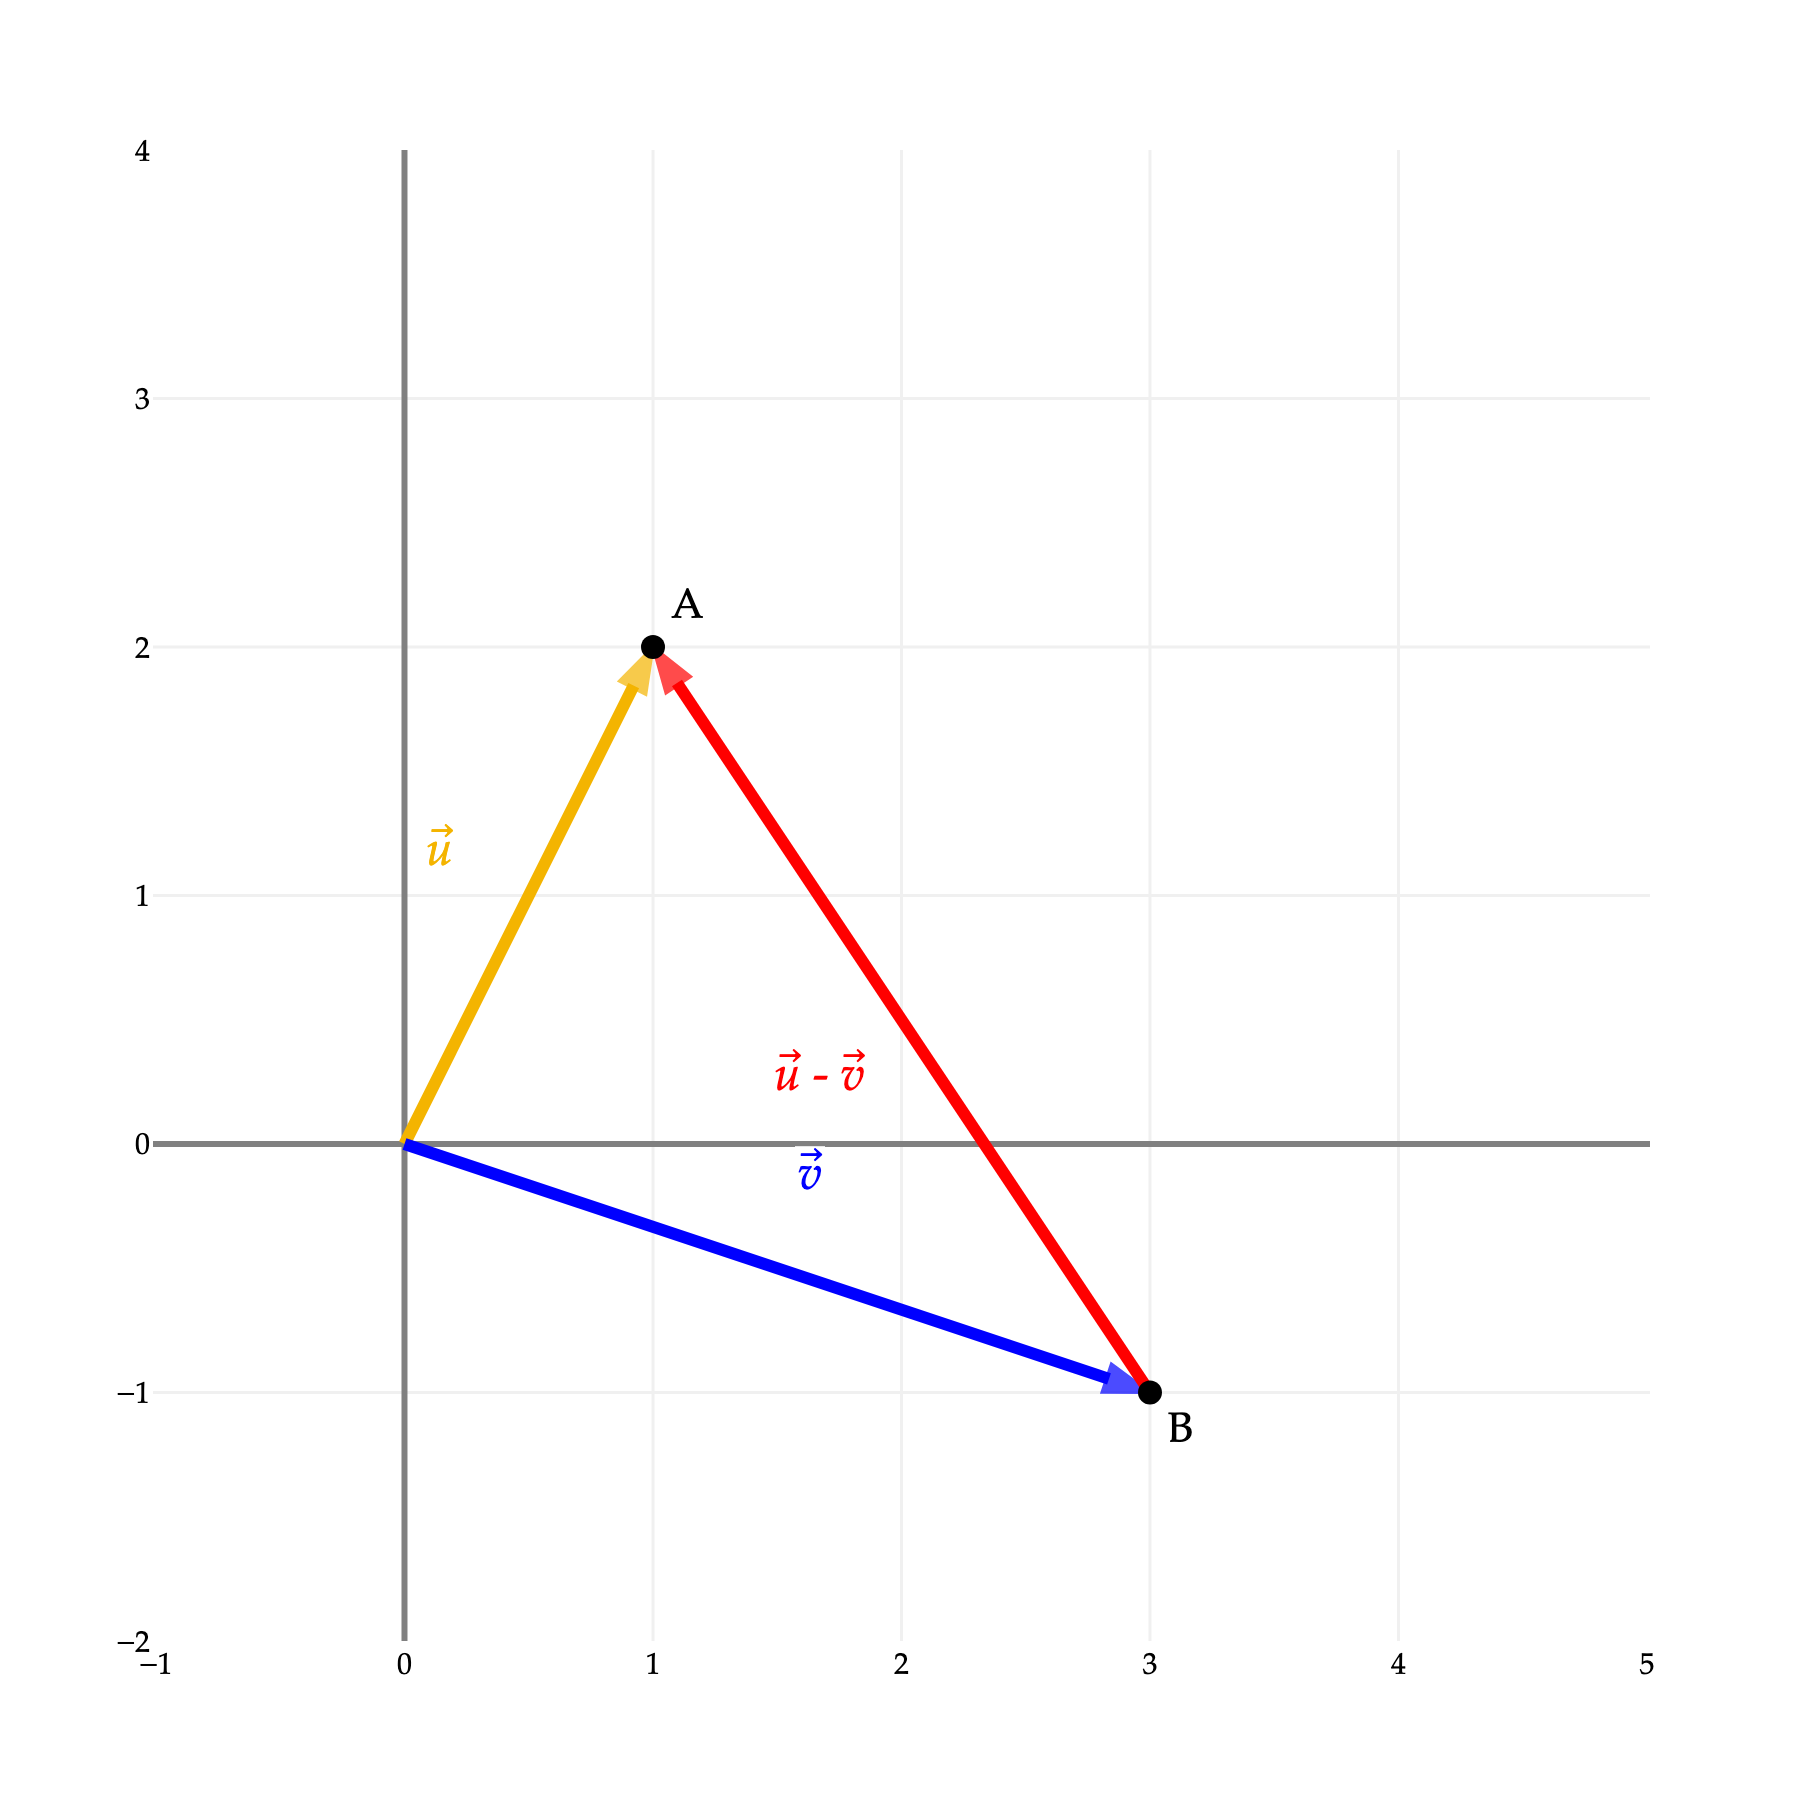

In [30]:
vectors = [
    (((0, 0), (1, 2)), '#f4b400', '<i>u</i>\u20D7'),
    (((0, 0), (3, -1)), 'blue', '<i>v</i>\u20D7'),
    (((3, -1), (1, 2)), 'red', '<i>u</i>\u20D7 - <i>v</i>\u20D7')
]

# Generate the figure using the custom utility
fig = plot_vectors_non_origin(vectors, vdeltax=0.4, vdeltay=0.4)


# Format the layout to keep the grid perfectly square
fig.update_layout(width=600, height=600, yaxis_scaleanchor="x")

fig.add_trace(go.Scatter(
    x=[1, 3],
    y=[2, -1],
    mode='markers+text',
    marker=dict(color='black', size=8),
    text=['A', 'B'],
    textposition=['top right', 'bottom right'],
    showlegend=False,
    hoverinfo='skip'
))

# Set the grid to comfortably frame the entire parallelogram
fig.update_xaxes(range=[-1, 5], tickvals=np.arange(-1, 6))
fig.update_yaxes(range=[-2, 4], tickvals=np.arange(-2, 5))

# Export statically
fig.show(scale=3)

### Computational Example

Let's look at an example in the 2D plane with points $A = (4, 3)$ and $B = (1, -1)$.
Their corresponding position vectors are $\vec{u} = \begin{bmatrix} 4 \\ 3 \end{bmatrix}$ and $\vec{v} = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$.

First, we calculate the displacement vector from $B$ to $A$:
$$\vec{u} - \vec{v} = \begin{bmatrix} 4 - 1 \\ 3 - (-1) \end{bmatrix} = \begin{bmatrix} 3 \\ 4 \end{bmatrix}$$

Then, we calculate the distance by taking the length of this displacement vector:
$$\|\vec{u} - \vec{v}\| = \sqrt{3^2 + 4^2} = \sqrt{9 + 16} = \sqrt{25} = 5$$

Hence the distance between the points $A$ and $B$ is exactly 5 units.

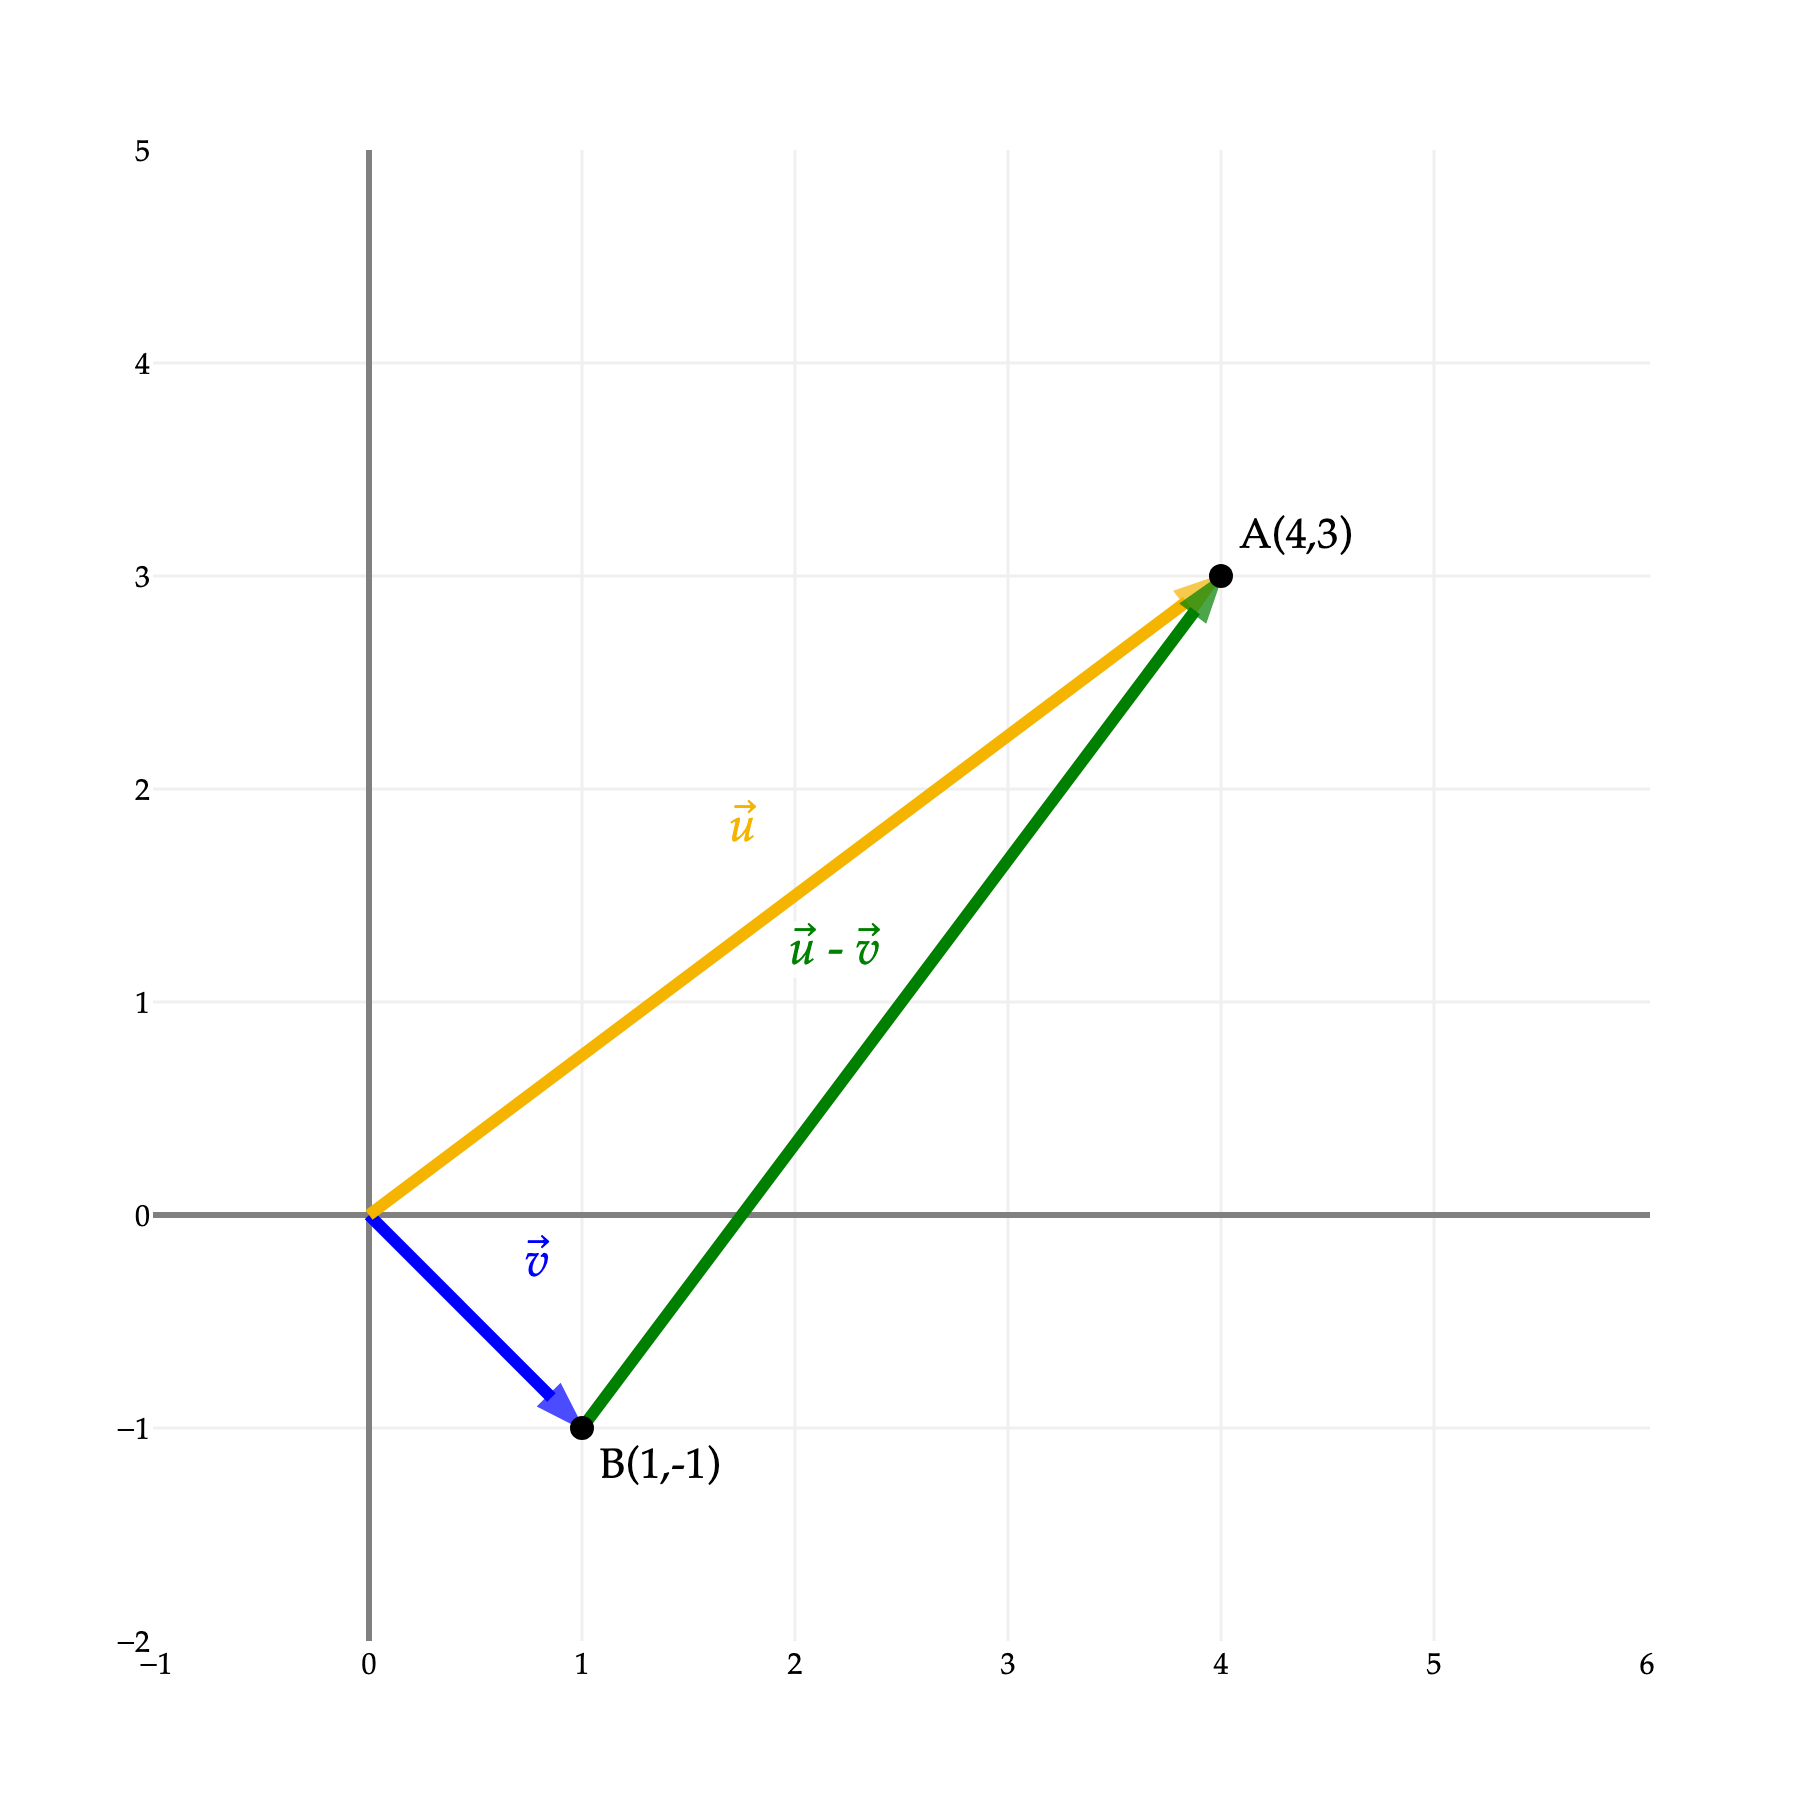

In [24]:
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"

# ---
from utils import plot_vectors_non_origin

# Define the vectors using standard strings and the Unicode combining right arrow (\u20D7)
vectors = [
    (((0, 0), (1, -1)), 'blue', '<i>v</i>\u20D7'),
    (((0, 0), (4, 3)), '#f4b400', '<i>u</i>\u20D7'),
    (((1, -1), (4, 3)), 'green', '<i>u</i>\u20D7 - <i>v</i>\u20D7')
]

# Generate the figure using the custom utility
fig = plot_vectors_non_origin(vectors, vdeltax=0.4, vdeltay=0.4)

# Explicitly mark and label points A and B
fig.add_trace(go.Scatter(
    x=[4, 1],
    y=[3, -1],
    mode='markers+text',
    marker=dict(color='black', size=8),
    text=['A(4,3)', 'B(1,-1)'],
    textposition=['top right', 'bottom right'],
    showlegend=False,
    hoverinfo='skip'
))

# Format the layout to keep the grid perfectly square
fig.update_layout(width=600, height=600, yaxis_scaleanchor="x")

# Set the grid to comfortably frame all points with integer ticks
fig.update_xaxes(range=[-1, 6], tickvals=np.arange(-1, 7))
fig.update_yaxes(range=[-2, 5], tickvals=np.arange(-2, 6))

# This should now export cleanly without the Error 525
fig.show(scale=3)

## The dot product

### Algebraic definition

Now let us move on to the concept of dot products. Given two vectors
$$\vec u = \begin{bmatrix} x_1 \\ \vdots \\ x_n \end{bmatrix},\ \vec v = \begin{bmatrix} y_1 \\ \vdots \\ y_n\end{bmatrix}, $$
the **dot product** of $\vec u$ and $\vec v$ is defined by
$$ \vec u \cdot \vec v = x_1 y_1 + x_2 y_2 + \ldots + x_n y_n.$$

Notice that if we take the dot product of a vector with itself, we get:
$$\vec u \cdot \vec u = x_1^2 + x_2^2 + \ldots + x_n^2.$$

This is exactly the square of the length of the vector. Therefore, we can express the length of any vector using the dot product:
$$\|\vec u\|^2 = \vec u \cdot \vec u.$$

Beyond calculating lengths, the dot product is really measuring how much two vectors "align" or "correlate" with each other algebraically. We will soon justify the following 
* If the dot product is **positive**, the vectors point in roughly the same direction, forming an acute angle.
* If the dot product is **zero**, the vectors are perfectly perpendicular, i.e. they are orthogonal.
* If the dot product is **negative**, the vectors point in roughly opposite directions, forming an obtuse angle.

Let's visualize this with a computational example in 2D space. We will take an anchor vector $\vec u = (2, 1)$ and compute its dot product with three different test vectors: $\vec v_{\text{aligned},1} = (1, 3)$, $\vec v_{\text{aligned},2} = (3, 3)$, $\vec v_{\text{ortho}} = (-1, 2)$, and $\vec v_{\text{opposed}} = (-2, -1)$.

Dot product (u, v_aligned,1): 5 (Positive -> Aligned)
Dot product (u, v_aligned,2): 9 (Positive -> Aligned)
Dot product (u, v_ortho): 0 (Zero -> Orthogonal)
Dot product (u, v_opposed): -5 (Negative -> Opposed)


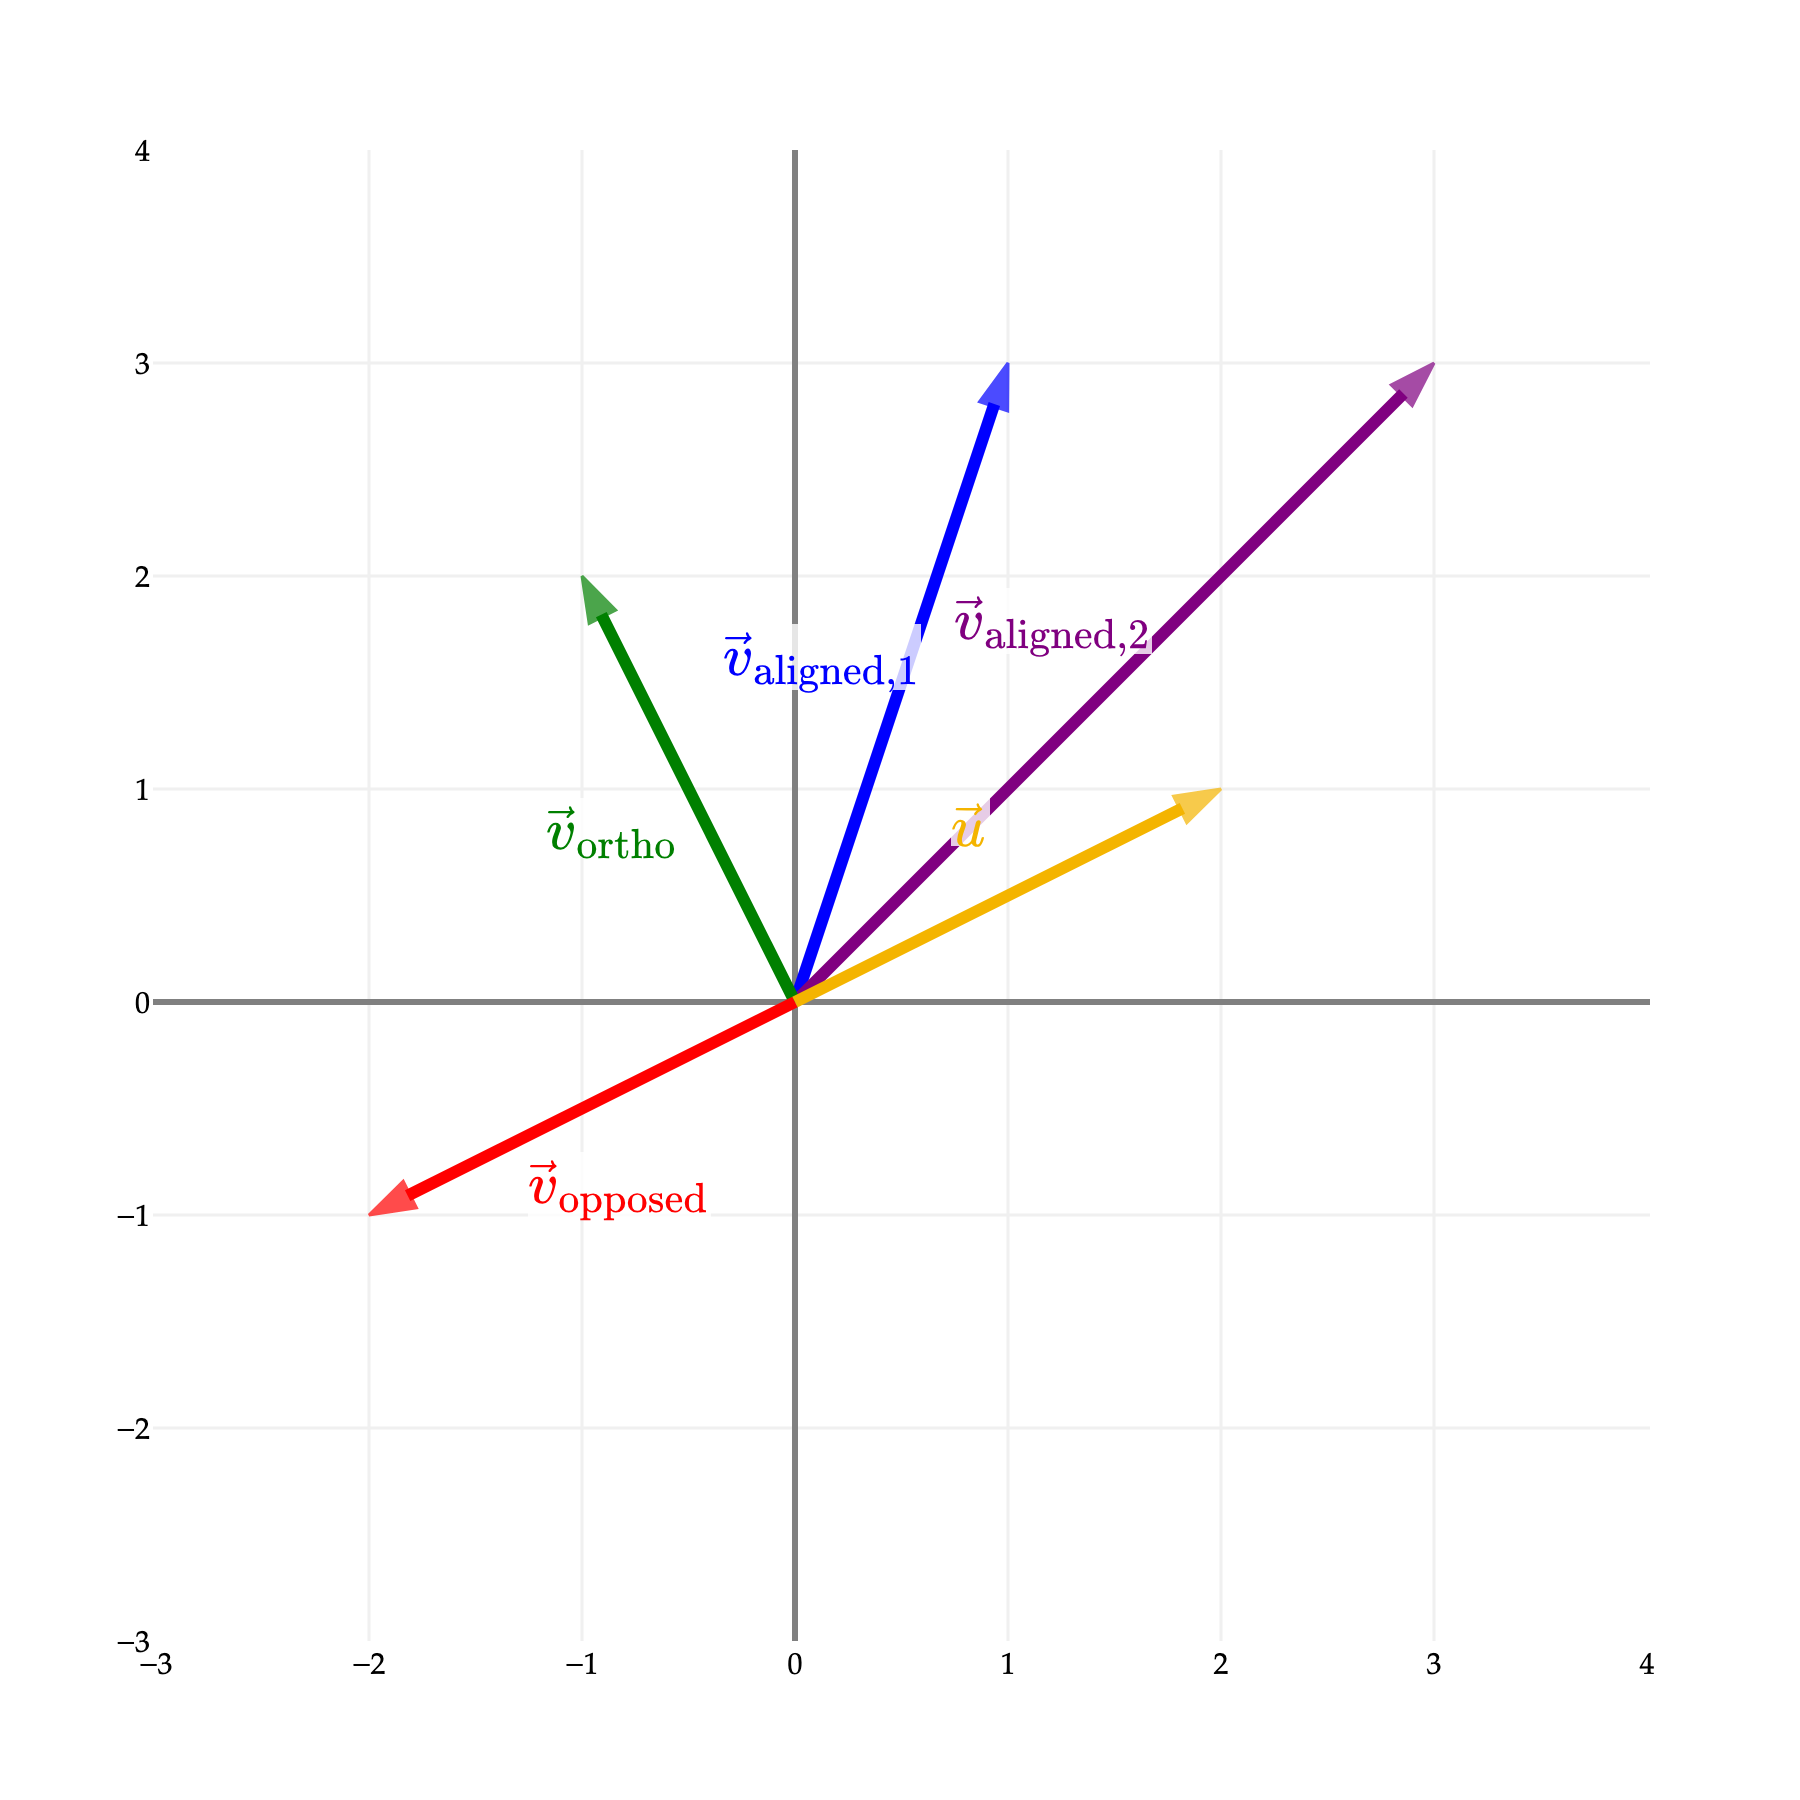

In [25]:
from IPython.display import display, HTML
import plotly.io as pio
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))

# ---
from utils import plot_vectors

# 1. Compute and print the dot products to demonstrate the algebraic correlation
u = np.array([2, 1])
v_aligned = np.array([1, 3])
v_aligned_2 = np.array([3, 3])
v_ortho = np.array([-1, 2])
v_opposed = np.array([-2, -1])

print(f"Dot product (u, v_aligned,1): {np.dot(u, v_aligned)} (Positive -> Aligned)")
print(f"Dot product (u, v_aligned,2): {np.dot(u, v_aligned_2)} (Positive -> Aligned)")
print(f"Dot product (u, v_ortho): {np.dot(u, v_ortho)} (Zero -> Orthogonal)")
print(f"Dot product (u, v_opposed): {np.dot(u, v_opposed)} (Negative -> Opposed)")

# 2. Define the vectors using your established tuple style: ((end_x, end_y), color, label)
vectors = [
    # Test vectors
    ((1, 3), 'blue', r'$\vec{v}_{\text{aligned},1}$'),
    ((3, 3), 'purple', r'$\vec{v}_{\text{aligned},2}$'),
    ((-1, 2), 'green', r'$\vec{v}_{\text{ortho}}$'),
    ((-2, -1), 'red', r'$\vec{v}_{\text{opposed}}$'),
    
    # Anchor vector (Gold, drawn last so it sits on top)
    ((2, 1), '#f4b400', r'$\vec{u}$')
]

# 3. Generate the figure using the custom utility
fig = plot_vectors(vectors, vdeltax=0.4, vdeltay=0.4)

# 4. Format the layout to keep the grid perfectly square
fig.update_layout(width=600, height=600, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-3, 4], tickvals=np.arange(-3, 5))
fig.update_yaxes(range=[-3, 4], tickvals=np.arange(-3, 5))

fig.show(scale=3)

### Basic properties

Let's first look at some basic properties of the dot product that will come in useful in computations.

#### Commutativity

Note from the algebraic formula that the order in which you take the dot product does not matter:
$$ \vec{u} \cdot \vec{v} = \vec{v} \cdot \vec{u} = x_1y_1 + \ldots + x_ny_n. $$
This property is called the _commutativity_ of the dot product.

#### Relation with addition and scalar multiplication

The dot product behaves well with addition and scalar multiplication:
$$ \vec{u} \cdot (\vec{v} + \vec{w}) = \vec{u} \cdot \vec{v} + \vec{u} \cdot \vec{w}, $$
$$ (t\vec{u}) \cdot \vec{v} = \vec u \cdot (t\vec v) = t(\vec{u} \cdot \vec{v}). $$


### The geometric formula

This geometric description of the dot product as measuring how 'aligned' the two vectors are can be made more precise. Let the angle between the two vectors $\vec u$ and $\vec v$ be $\theta$, then the dot product is equal to
$$ \vec u \cdot \vec v  = \| \vec u \| \| \vec v \| \cos \theta.$$

Note that if the two vectors form an acute angle, $\theta$ is between $0^{\circ}$ and $90^{\circ}$, for which $\cos\theta$ is positive. Hence $\vec u \cdot \vec v$ must be positive. Similarly, if the two vectors form an obtuse angle, $\theta$ is between $90^{\circ}$ and $180^{\circ}$. It follows that $\cos\theta$ and $\vec u \cdot \vec v$ is negative.

The most important observation here is that for non-zero vectors $\vec u$ and $\vec v$, the dot product is zero when $\cos \theta  = 0$. This occurs precisely when $\theta$ is 90 degrees, i.e. when the two vectors are perpendicular. Hence we have the following criterion for non-zero vectors $\vec u$ and $\vec v$:
$$ \vec u \perp \vec v \text{ precisely when } \vec u \cdot \vec v = 0.$$
This can be made sense from the viewpoint of correlation as well. If the two vectors are perpendicular, there is no correlation in the directions at which they are pointing, hence the dot product is zero. This criterion is very important will be used repeatedly for the remainder of the course.

We present one application of this geometric description of the dot product. In particular, we can find the angle between two vectors -- which may not be apparent from pictures -- by computing their dot product algebraically.

Consider the two vectors $\vec u = \begin{bmatrix} 2 \\ 1 \end{bmatrix}$ and $\vec v = \begin{bmatrix} 2 \\ 6 \end{bmatrix}$. Suppose we want to find the angle $\theta$ between the two vectors. By our geometric formula, we have
$$\begin{align*}
&\vec u \cdot \vec v = \begin{bmatrix} 2 \\ 1 \end{bmatrix} \cdot \vec v = \begin{bmatrix} 2 \\ 6 \end{bmatrix} = 2\cdot 2 + 1 \cdot 6 = 10 \\
&= \| \vec u\| \| \vec v\| \cos\theta = \sqrt{2^2 + 1}\sqrt{2^2+ 6^2}\cos \theta = \sqrt{5}\sqrt{40}\cos\theta = 10\sqrt{2}\cos\theta,
\end{align*}$$
from which we obtain
$$\cos\theta = \frac{1}{\sqrt 2},\ \theta = 45^{\circ}.$$

Note that it is not immediately clear that the angle between the vectors $\vec u$ and $\vec v$ is 45 degrees just from the picture below; we really needed to use the dot product here.


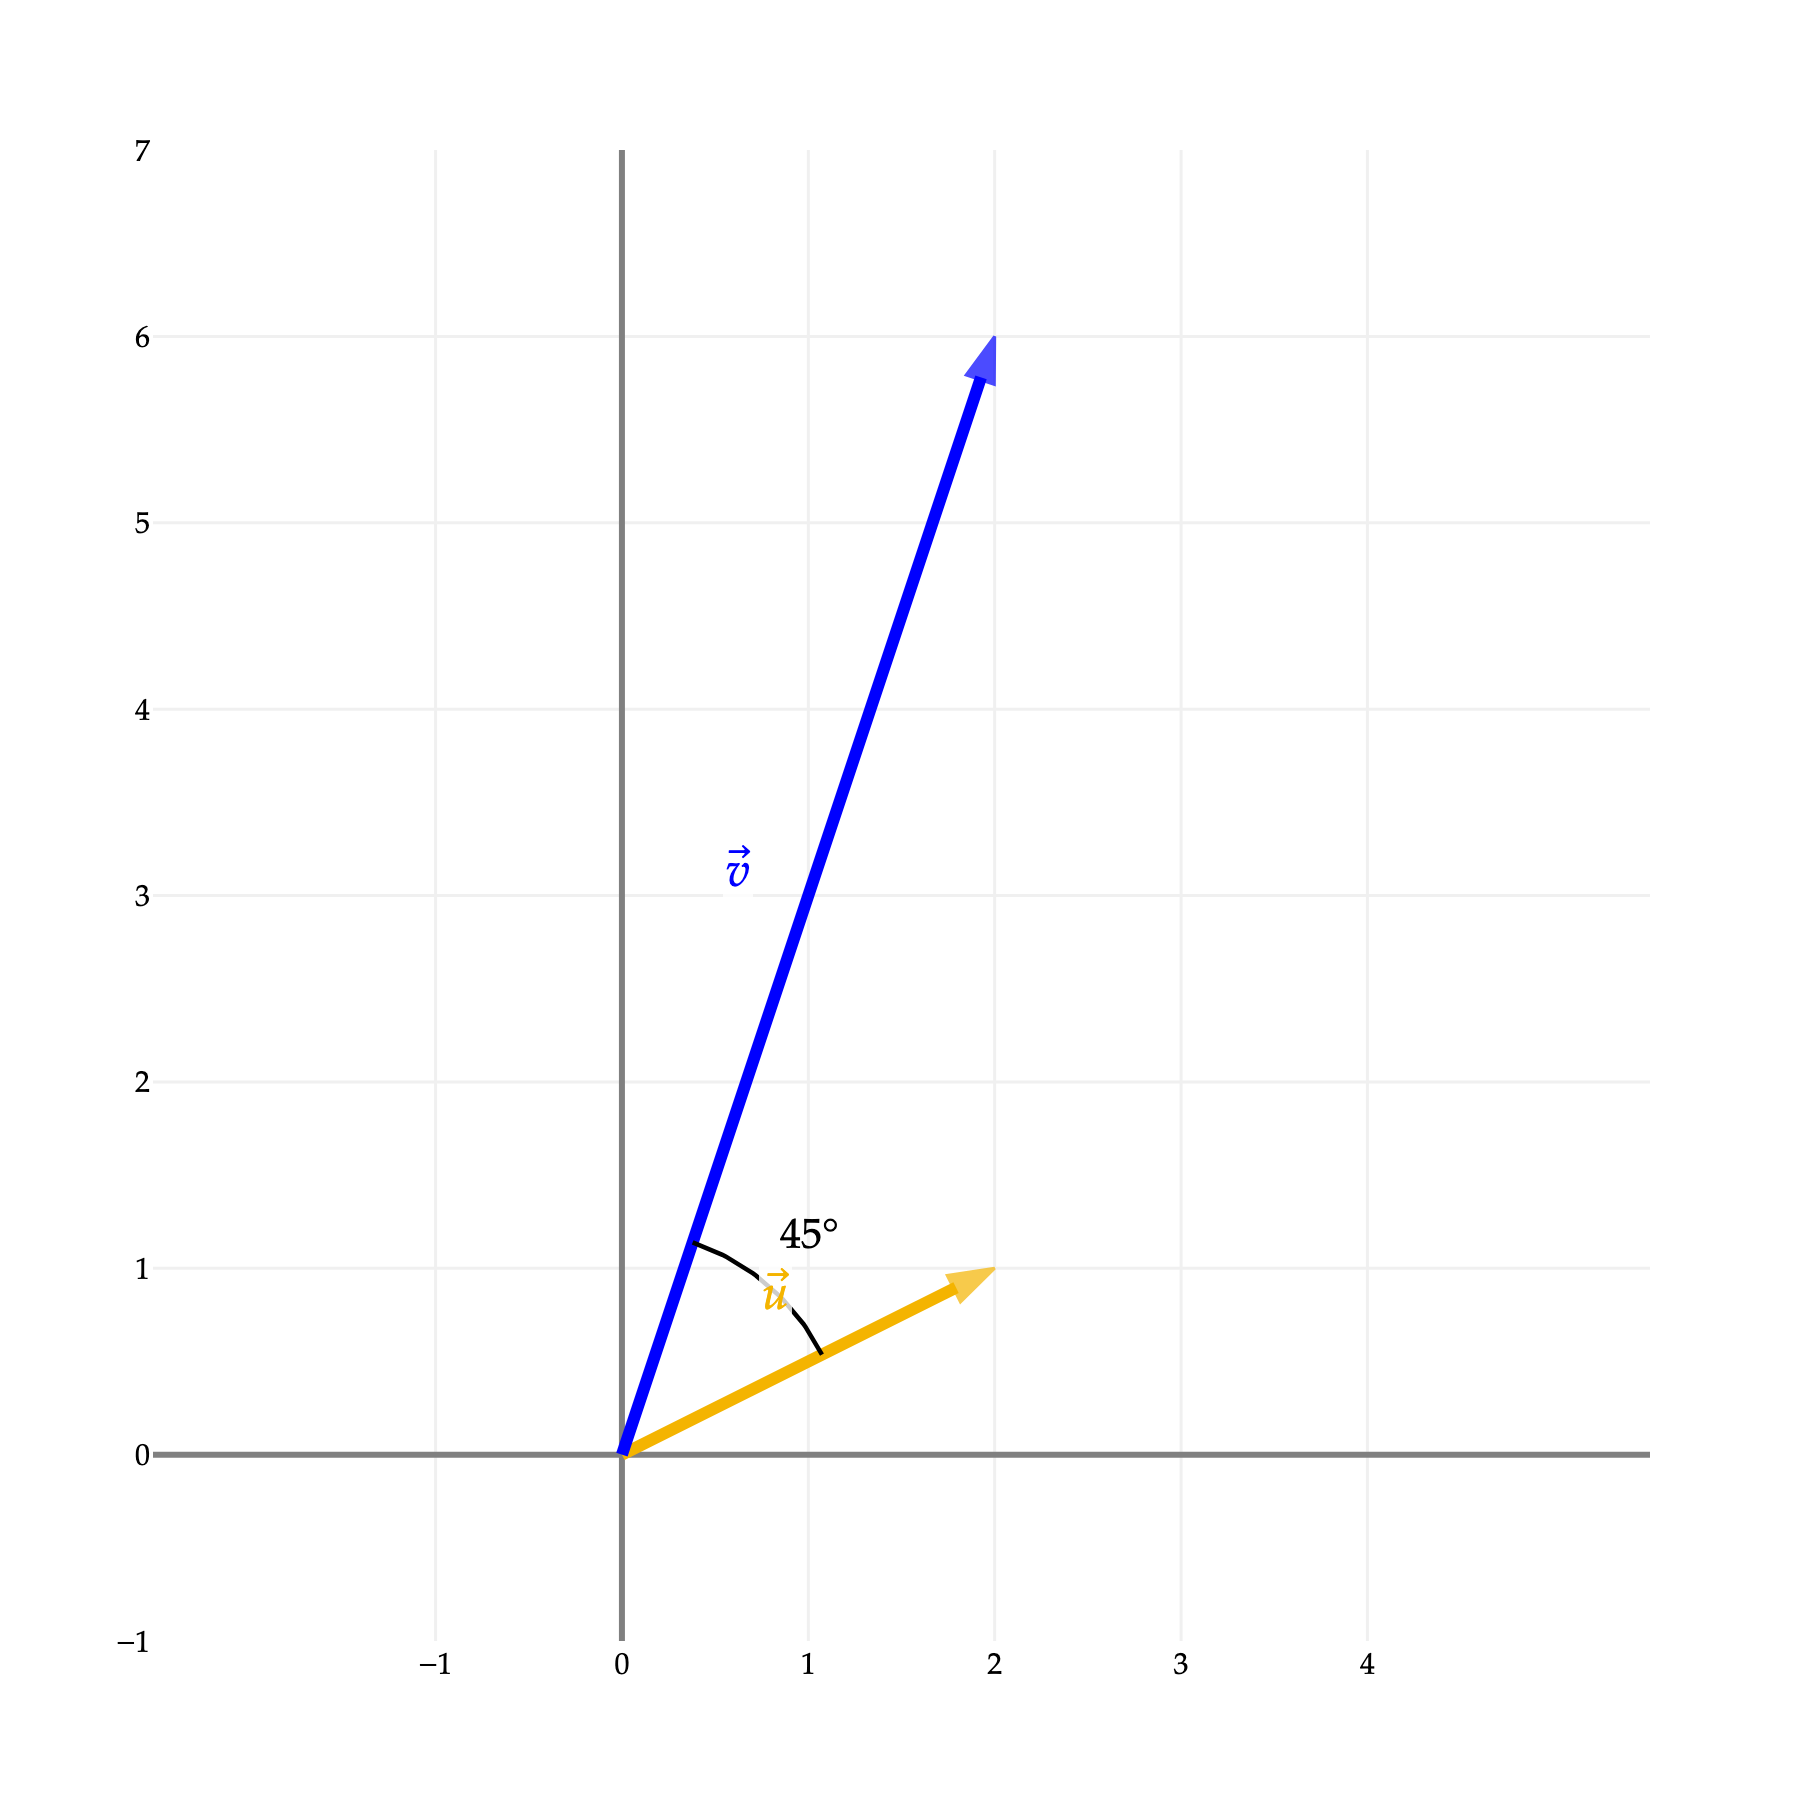

In [ ]:
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"

# ---
from utils import plot_vectors

# Define the vectors using standard strings and the Unicode combining right arrow (\u20D7)
vectors = [
    ((2, 1), '#f4b400', '<i>u</i>\u20D7'),
    ((2, 6), 'blue', '<i>v</i>\u20D7')
]

# Generate the figure using the custom utility
fig = plot_vectors(vectors, vdeltax=0.4, vdeltay=0.4)

# Add an arc to explicitly denote the 45 degree angle
# We calculate the start and end angles using arctan2(y, x)
theta_u = np.arctan2(1, 2)
theta_v = np.arctan2(6, 2)
theta_arc = np.linspace(theta_u, theta_v, 50)

r = 1.2  # Radius of the angle arc
x_arc = r * np.cos(theta_arc)
y_arc = r * np.sin(theta_arc)

fig.add_trace(go.Scatter(
    x=x_arc, y=y_arc, mode='lines', 
    line=dict(color='black', width=1.5), showlegend=False, hoverinfo='skip'
))

# Label the 45 degree angle mathematically in the middle of the arc
theta_mid = (theta_u + theta_v) / 2
r_text = r + 0.35
fig.add_annotation(
    x=r_text * np.cos(theta_mid), 
    y=r_text * np.sin(theta_mid), 
    text="45°", showarrow=False, font=dict(size=14)
)

# Format the layout to keep the grid perfectly square
fig.update_layout(width=600, height=600, yaxis_scaleanchor="x")

# Set the grid to comfortably frame the vectors
fig.update_xaxes(range=[-1, 4], tickvals=np.arange(-1, 5))
fig.update_yaxes(range=[-1, 7], tickvals=np.arange(-1, 8))

# Export statically to prevent the Kaleido 525 Error
fig.show(scale=3)

## Application of the dot product in science & engineering

To be filled!!